# Descriptive Statistics

Learning Objectives
 - Compute mean, median, and mode and choose the appropriate one for a given dataset.
 - Compute and interpret variance, standard deviation, and IQR.
 - Explain how outliers affect each measure differently.


# Section 1 : Data loading and preperation

### Heart Disease Dataset

#### About the Dataset:
This data set dates from 1988 and consists of four databases: Cleveland, Hungary, Switzerland, and Long Beach V. It contains 76 attributes, including the predicted attribute, but all published experiments refer to using a subset of 14 of them. The "target" field refers to the presence of heart disease in the patient. It is integer valued 0 = no disease and 1 = disease.

#### Link: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

#### Columns Description

| Column | Description | Data Type |
|--------|-------------|-----------|
| `age` | Age of the patient in years | Numeric |
| `sex` | Sex of the patient (1 = male, 0 = female) | Binary |
| `cp` | Chest pain type (4 possible values) | Categorical |
| `trestbps` | Resting blood pressure in mm Hg | Numeric |
| `chol` | Serum cholesterol level in mg/dl | Numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Binary |
| `restecg` | Resting electrocardiographic results (values 0, 1, 2) | Categorical |
| `thalach` | Maximum heart rate achieved | Numeric |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) | Binary |
| `oldpeak` | ST depression induced by exercise relative to rest | Numeric |
| `slope` | Slope of the peak exercise ST segment | Categorical |
| `ca` | Number of major vessels (0-3) colored by fluoroscopy | Numeric |
| `thal` | Thalassemia status (0 = normal, 1 = fixed defect, 2 = reversible defect) | Categorical |
| `target` | Presence of heart disease (1 = disease, 0 = no disease) | Binary |


### Dataset preperation

In [1]:
import os
import numpy as np
import pandas as pd
print(os.listdir())  # had an issue where the dataset isnt found so I added this function to check if the jupyter sees it

['.ipynb_checkpoints', 'Day_1_Descriptive Statistics.ipynb', 'heart.csv', 'kc_house_data.csv']


In [3]:
df = pd.read_csv("heart.csv")
df.head()                              # first 5 rows
df.shape                               # (rows, columns)
df.info()                              # column names, non-null counts, dtypes
df.describe()                          # summary statistics for numeric columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [36]:
df.isnull().sum() # The function returned 0 meaning there werent any missing values in the columns

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

# Section 2 : Learnings

## **Topic 1 :** Measure of Central Tendency
> The measure of central tendency is a **single value** that attempts to describe the whole set of data. There are three main features of central tendency:

- **Mean :**  avarage of the whole column
- **Median :** middle element of data. 
    - Median Low
    - Median High
- **Mode :**  middle value of the data set

### 1. Mean (Arithmetic Average)

> It is the sum of observations divided by the total number of observations. It is also defined as **average** which is the sum divided by count. 

#### Formula:

$\
\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}
\$

Where:
- $\bar{x}$ = mean of the dataset
- $x_i$ = each individual value
- $n$ = total number of observations
- $\sum$ = summation of all values

#### Function:
The `mean()` function returns the mean or average of the data passed in its arguments. If the passed argument is empty, StatisticsError is raised.

In [21]:
data = np.array([10, 12, 12, 13, 100])
print("the avarage number of the list [10, 12, 12, 13, 100] : " , np.mean(data)) 
print("avarage age in this dataset : " , df["age"].mean())
 

the avarage number of the list [10, 12, 12, 13, 100] :  29.4
avarage age in this dataset :  54.43414634146342


### 2. Median (Middle Value)

> It is the middle value of the data set. It splits the data into two halves. If the number of elements in the data set is odd then the center element is the median and if it is even then the median would be the average of two central elements. it first sorts the data i=and then performs the median operation

#### Formula (Odd number of observations):
$$
Median = X_{\frac{n+1}{2}}
$$
#### Formula (Even number of observations):
$$
Median = \frac{X_{\frac{n}{2}} + X_{\frac{n}{2}+1}}{2}
$$
Where:
- $X$ = sorted dataset
- $n$ = number of observations

### Example (Odd dataset):
Dataset:
$$
X=\{10,20,30,40,50\}
$$

The middle position is:
$$
\frac{n+1}{2}=\frac{5+1}{2}=3
$$
Therefore:
$$
Median=X_3=30
$$

### Example (Even dataset):

Dataset:

$$
X=\{10,20,30,40\}
$$
The two middle values are 20 and 30:
$$
Median=\frac{20+30}{2}
$$

$$
Median=25
$$


#### Function
The `median()` function is used to calculate the median, i.e middle element of data. If the passed argument is empty, StatisticsError is raised.

In [23]:
data = np.array([10, 12, 12, 13, 100])
print("the middle value of the list [10, 12, 12, 13, 100] : " , np.median(data)) 
print("the middle value of the ages in this dataset : " , df["age"].median())

the middle value of the list [10, 12, 12, 13, 100] :  12.0
the middle value of the ages in this dataset :  56.0


### 3. Mode (Most Frequent Value)

> #### The mode is the value that appears most frequently in a dataset.

#### Formula:

$$
Mode = \operatorname{argmax}_{x} f(x)
$$

Where:
- $f(x)$ = frequency of value $x$
- $\operatorname{argmax}$ = the value that has the highest frequency

#### Example:

Dataset:
$$
X=\{1,2,2,3,4\}
$$
Frequency:
- 1 appears once
- 2 appears twice
- 3 appears once
- 4 appears once

Therefore:
$$
Mode=2
$$
#### Funcrion 
The `mode()` function returns the number with the maximum number of occurrences. If the passed argument is empty, StatisticsError is raised.

In [38]:
data = np.array([10, 12, 12, 13, 100]) 
# print("Mode of data set 1 is % s" % (mode(data))) 
print("Most common age in this dataset : " , df["age"].mode()[0])

Most common age in this dataset :  58


## **Topic 2 :** Measures of Spread

> Measures of spread (also called measures of variability or dispersion) **describe how spread out or scattered a set of data values is.** While measures of central tendency (like mean or median) tell us the center, **measures of spread tell us how much the data varies around that center.**

Measures of spread help us answer questions such as:
- How similar are the observations?
- How much variation exists in the data?
  > 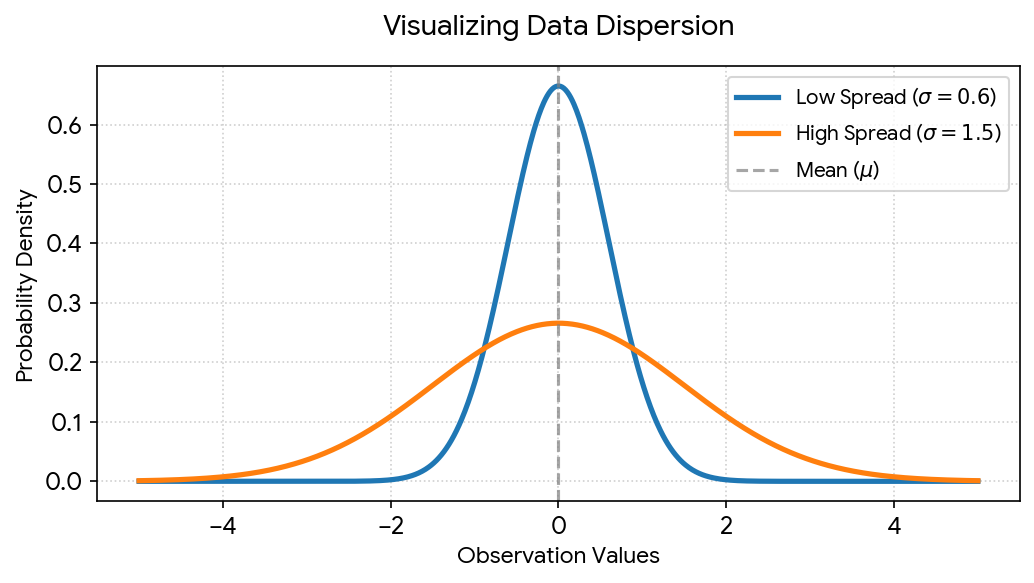
- Are there outliers?
   > Outliers are data points that are significantly different or lie an abnormal distance from the rest of the observations in a dataset
   > 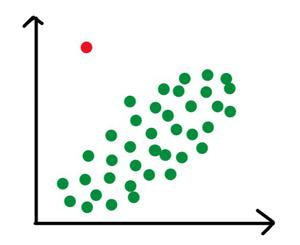
- Is the data concentrated or widely dispersed?

### 1) Range
> The Range is the simplest measure of spread.
It is calculated by subtracting the smallest value from the largest value.

#### Formula
$$
Range = x_{max}-x_{min}
$$
Where:
- $x_{max}$ = largest value
- $x_{min}$ = smallest value

**A small range** means the values are relatively close together.

**A large range** means the values are spread farther apart.


In [70]:
# Age range

age_range = df["age"].max() - df["age"].min()

print("Age range:", age_range)
print("Age mean:", df["age"].mean())
print("Age median:", df["age"].median())

print("\n")

# Cholesterol range

chol_range = df["chol"].max() - df["chol"].min()

print("Cholesterol range:", chol_range)
print("Cholesterol mean:", df["chol"].mean())
print("Cholesterol median:", df["chol"].median())


Age range: 48
Age mean: 54.43414634146342
Age median: 56.0
Age standard deviation: 9.072290233244281


Cholesterol range: 438
Cholesterol mean: 246.0
Cholesterol median: 240.0
Cholesterol standard deviation: 51.59251020618206


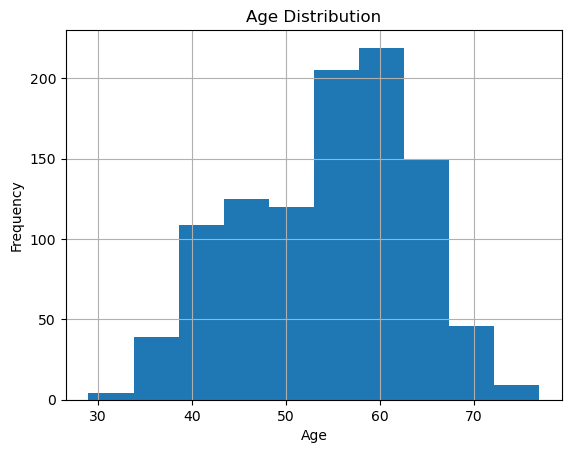

In [89]:
import matplotlib.pyplot as plt
df["age"].hist(bins=10)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()

This histogram shows that most pasients are concentrated between 54-70 years 

### 2) Variance
>Variance measures **how far the observations are from the mean.**
Instead of only looking at the smallest and largest values, variance considers every observation.
Because some observations are above the mean and others are below it, simply adding the distances would cancel out to zero.
To solve this problem, we square every distance. 

#### Formula (Population Variance)
$$
\sigma^2=
\frac{\sum_{i=1}^{n}(x_i-\mu)^2}{n}
$$

#### Formula (Sample Variance)

$$
s^2=
\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}
$$

Where:

- $x_i$ = each observation
- $\mu$ = population mean
- $\bar{x}$ = sample mean
- $n$ = number of observations

#### How Variance Works

**1. Suppose**

20,22,24,26,28

Mean

$$
24
$$

**2. Distances from the mean (observation - mean)**

-4,-2,0,2,4

**3. Square each distance**

16,4,0,4,16

**4. Add them**

$$
16+4+0+4+16=40
$$

**5. Population variance**

$$
\frac{40}{5}=8
$$

#### Interpretation

- **Small variance**

> Values are close to the average.

- **Large variance**

> Values are spread far from the average.

#### Function

NumPy
`np.var(array)
`

Pandas
`df["comun_name"].var()`


In [6]:
print("chol mean:", df["chol"].mean())
print("Variance in chol : ", df["chol"].var())

chol mean: 246.0
Variance in chol :  2661.787109375


#### Limitation

Variance is measured in squared units.

For example

- Age → years²
- Cholesterol → (mg/dL)²

This makes variance difficult to interpret directly.

For that reason, **we usually use Standard Deviation**

### 3) Standard Deviation
> Standard deviation **is the square root of the variance.**
Unlike variance, it has the same units as the original data, making it much easier to interpret.

#### Formula

$$
\sigma=\sqrt{\sigma^2}
$$



#### Function
NumPy
`np.std(array)`
Pandas
`df["column_name"].std()`

In [7]:
print("Age standard deviation:", df["age"].std())
print("Cholesterol standard deviation:", df["chol"].std())

Age standard deviation: 9.072290233244281
Cholesterol standard deviation: 51.59251020618206


#### Interpretation

Suppose

Average cholesterol

$$
240;mg/dL
$$

Standard deviation

$$
20;mg/dL
$$

This tells us that most cholesterol values are roughly 20 mg/dL away from the average.

- Small standard deviation

> Data points are close to the mean.

- Large standard deviation

> Data points are spread over a wider range.

### 4) IQR (interquartile range) 
> The Interquartile Range (IQR) measures the spread of the middle 50% of the data.
> Instead of using the minimum and maximum values, it focuses only on the central portion of the dataset.
> Because of this, **it is much less affected by outliers.**

#### How to Calculate IQRSort data: 
1. Arrange all numbers from least to greatest.
2. Find median: Locate the middle value (Q₂) to split the data into lower and upper halves.
3. Find Q₁ and Q₃:
> - Q₁ is the median of the lower half.
> - Q₃ is the median of the upper half.

4. Subtract: Compute IQR = Q₃ - Q₁.

#### Formula

$$
IQR=Q_3-Q_1
$$

Where

- $Q_1$ = First Quartile (25th percentile)
- $Q_3$ = Third Quartile (75th percentile)

In [23]:
q1 = df["chol"].quantile(0.25)  # 25% of the data
q3 = df["chol"].quantile(0.75)  # 75% of the data
iqr = q3-q1 
print(iqr)

64.0


In [25]:
data = np.array( df["chol"])
print(data)
q1, q3 = np.percentile(data, [25, 75])
print(q3 - q1)

[212 203 174 ... 275 254 188]
64.0


`0.25` means 25% of the data (the first quartile).

`0.75` means 75% of the data (the third quartile).

## **Topic 3 :** Percentiles and Quartiles

A **percentile** marks the value below which a given percentage of the data falls.
For example, if a value is at the 75th percentile, it means 75% of all data points
fall below it.

**Quartiles** are just three specific percentiles that split the data into four
equal quarters:

- **Q1 (25th percentile)** — 25% of the data falls below this value
- **Q2 (50th percentile)** — this is the **median**, the middle of the dataset
- **Q3 (75th percentile)** — 75% of the data falls below this value


```
Lowest                                            Highest

|---------------------------------------------------------|
126      197          240          265                564
          ↑            ↑            ↑
         Q1       Median (Q2)      Q3
```

# Section 3 : Hands-on lap

## Step 1: Load a numeric column from a provided dataset into a NumPy array or Pandas Series

In [87]:
# Loading the age column as a Pandas Series
age_series = df["age"]
print(age_series.head(15))

print()
# Load the age column as a NumPy array
#age_array = df["age"].to_numpy()


0     52
1     53
2     70
3     61
4     62
5     58
6     58
7     55
8     46
9     54
10    71
11    43
12    34
13    51
14    52
Name: age, dtype: int64



## Step 2: Compute its mean, median, mode, standard deviation, and IQR

In [27]:
print("Mean:", df["chol"].mean())
print("Variance:", df["chol"].var())
print("Standard Deviation:", df["chol"].std()) 
print("Range:", df["chol"].max()-df["chol"].min())

q1 = df["chol"].quantile(0.25)  # 25% of the data
q3 = df["chol"].quantile(0.75)  # 75% of the data
iqr = q3-q1 
print("IQR: " ,iqr)

Mean: 246.0
Variance: 2661.787109375
Standard Deviation: 51.59251020618206
Range: 438
IQR:  64.0


In [28]:
frequent_vals = df['chol'].mode()
print(frequent_vals)

0    204
1    234
Name: chol, dtype: int64


## Step 3: Identify whether the mean or median better represents a 'typical' value, and justify the choice.

### what is a typical value? 
> It is one value that represents most of the data best

### what is a typical value? 
> It is one value that represents most of the data best

### First we calculate both `mean` and `median` for the numerical column `oldpeak`

In [42]:
print("Mean:", df["oldpeak"].mean())
print("Median:", df["oldpeak"].median())

Mean: 1.0715121951219515
Median: 0.8


### Or we use `describe()`

In [40]:
print(df["oldpeak"].describe())

count    1025.000000
mean        1.071512
std         1.175053
min         0.000000
25%         0.000000
50%         0.800000
75%         1.800000
max         6.200000
Name: oldpeak, dtype: float64


### Then, we illustrate the distribution of the data

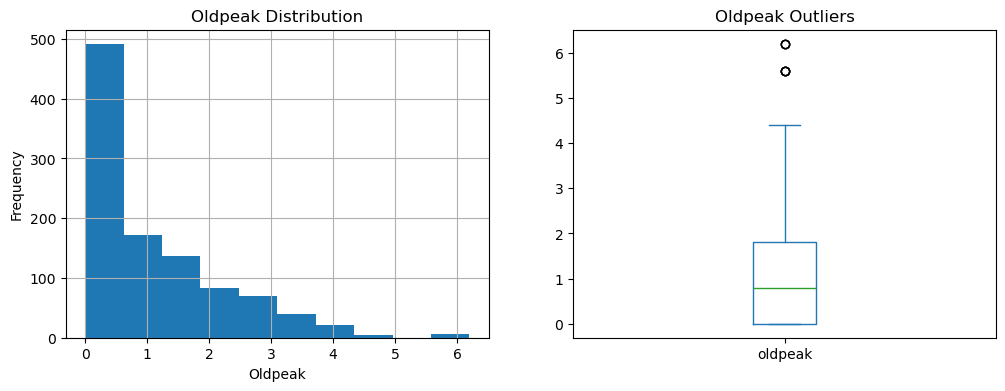

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
df["oldpeak"].hist(bins=10, ax=axes[0])
axes[0].set_title("Oldpeak Distribution")
axes[0].set_xlabel("Oldpeak")
axes[0].set_ylabel("Frequency")

# Box plot
df["oldpeak"].plot(kind="box", ax=axes[1])
axes[1].set_title("Oldpeak Outliers")

plt.show()

 #### According to both diagrams, the median is a better representation of the data than the mean value. Because there are a few `oldpeak` outlier values that cause the mean to be `1.07` , meaning there are few data points affecting the overall representation of the data. The median excludes outliers, so the value `0.8` is more suitable to represent the majority.

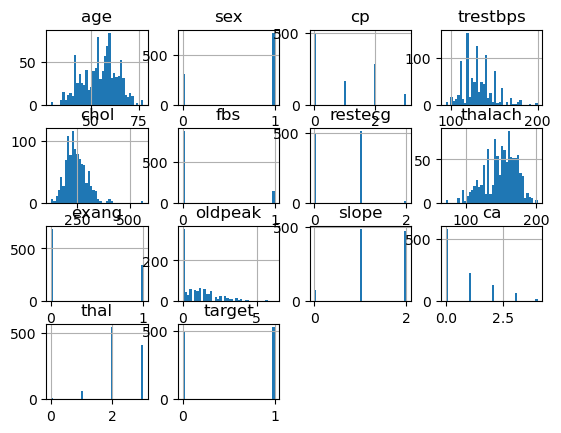

In [47]:
df.hist(bins=40)

plt.xlabel("Oldpeak (ST Depression)")
plt.ylabel("Frequency")
plt.title("Distribution of Oldpeak")

plt.show()

####   This same pattern applies to columns like `ca` and `trestbps`, where the histogram is right-skewed and a few data points push the values very high on one side. In these cases, the median is also the better choice to represent the majority.